# 🐄 Cattle Breed Classifier — Best Accuracy (Google Colab)
### EfficientNetB0 · MobileNetV2 · ResNet50 · CNN from Scratch · ViT

**Google Colab Setup:**
1. `Runtime → Change runtime type → GPU (T4 or A100)`
2. Upload your dataset ZIP to Colab or mount Google Drive
3. Set `DATA_DIR` in Cell 2
4. `Runtime → Run all`


In [1]:
# ══════════════════════════════════════════════════
# CELL 1 — Install dependencies & imports
# ══════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Install timm (PyTorch is pre-installed on Colab GPU runtimes)
try:
    import timm
    print('timm already installed:', timm.__version__)
except ImportError:
    pip('timm')
    import timm

# Core imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os, random, json, shutil, math
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Allow inline plots in Colab/Jupyter
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    matplotlib.use('module://matplotlib_inline.backend_inline')
except Exception:
    pass

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

# Mixed precision — speeds up training on T4/A100 with no accuracy loss
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision: float16 enabled')
except Exception as e:
    print('Mixed precision not enabled:', e)

all_results = {}
print('\n✅ All imports successful.')


timm already installed: 1.0.26
TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: float16 enabled

✅ All imports successful.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ══════════════════════════════════════════════════
# CELL 2 — Config
# ══════════════════════════════════════════════════


DATA_DIR = '/content/drive/MyDrive/capstone2/cattle_datasets'

# ── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = '/content/cattle_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 64          # ⚡ FAST MODE: increased for speed (reduce to 16 if GPU OOM)
EPOCHS_WARMUP   = 3           # ⚡ FAST MODE: reduced from 10 (was: frozen backbone warm-up)
EPOCHS_FINETUNE = 10          # ⚡ FAST MODE: reduced from 40 (early stopping active)
VAL_SPLIT       = 0.2
SEED            = 42
LABEL_SMOOTHING = 0.1

# ── Validate dataset path ─────────────────────────────────────────────────────
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f'Dataset folder not found: {DATA_DIR}\n'
        'Please set DATA_DIR correctly using one of the options above.'
    )

class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
NUM_CLASSES = len(class_names)
assert NUM_CLASSES >= 2, 'Need at least 2 class folders inside DATA_DIR'

print(f'Dataset   : {DATA_DIR}')
print(f'Classes ({NUM_CLASSES}): {class_names}')
print(f'Output    : {OUTPUT_DIR}')


Dataset   : /content/drive/MyDrive/capstone2/cattle_datasets
Classes (5): ['Gir', 'Holstein Friesian', 'Jersey', 'Tharparkar', 'sahiwal']
Output    : /content/cattle_outputs


In [6]:
# ══════════════════════════════════════════════════
# CELL 3 — Shared Utilities
# ══════════════════════════════════════════════════

def save_to_output(path):
    """Copy a file to OUTPUT_DIR and return destination path."""
    dst = os.path.join(OUTPUT_DIR, os.path.basename(path))
    shutil.copy2(path, dst)
    return dst

# ── Callbacks ─────────────────────────────────────────────────────────────────
def get_callbacks(model_name, patience_es=5, use_reduce_lr=True):
    """
    Returns EarlyStopping + ModelCheckpoint (+ optional ReduceLROnPlateau).
    Set use_reduce_lr=False when using a CosineDecay LR schedule.
    """
    ckpt_path = os.path.join(OUTPUT_DIR, f'best_{model_name}.keras')
    cb = [
        EarlyStopping(monitor='val_accuracy', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                        save_best_only=True, verbose=0),
    ]
    if use_reduce_lr:
        cb.append(ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=2, min_lr=1e-8, verbose=1))
    return cb

# ── Data generators — augmentation always ON ──────────────────────────────────
def get_generators(use_preprocess_fn=None):
    """
    use_preprocess_fn: backbone-specific preprocess_input function.
    Pass None to use plain rescale=1/255 (CNN-scratch).
    """
    common_kwargs = dict(
        validation_split=VAL_SPLIT,
    )
    if use_preprocess_fn is not None:
        common_kwargs['preprocessing_function'] = use_preprocess_fn
    else:
        common_kwargs['rescale'] = 1.0 / 255.0

    train_datagen = ImageDataGenerator(
        **common_kwargs,
        rotation_range=35,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.2,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        channel_shift_range=25.0,
        fill_mode='reflect',
    )
    val_datagen = ImageDataGenerator(**common_kwargs)

    train_gen = train_datagen.flow_from_directory(
        DATA_DIR, target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='training', shuffle=True, seed=SEED)
    val_gen = val_datagen.flow_from_directory(
        DATA_DIR, target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='validation', shuffle=False, seed=SEED)
    return train_gen, val_gen

# ── Class weights ──────────────────────────────────────────────────────────────
def get_class_weights(train_gen):
    labels  = train_gen.classes
    unique  = np.unique(labels)
    weights = compute_class_weight('balanced', classes=unique, y=labels)
    cw      = dict(zip(unique.tolist(), weights.tolist()))
    idx2cls = {v: k for k, v in train_gen.class_indices.items()}
    print('Class weights:')
    for i, w in cw.items():
        print(f'  [{i}] {idx2cls[i]}: {w:.3f}')
    return cw

# ── Cosine decay LR schedule ───────────────────────────────────────────────────
def cosine_lr_schedule(steps_per_epoch, epochs, initial_lr=2e-5, alpha=1e-7):
    return tf.keras.optimizers.schedules.CosineDecay(
        initial_lr, steps_per_epoch * epochs, alpha=alpha)

# ── Evaluation ─────────────────────────────────────────────────────────────────
def evaluate_model(model, val_gen, model_name):
    val_gen.reset()
    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f'{model_name} — Val Accuracy: {acc*100:.2f}%  Loss: {loss:.4f}')
    val_gen.reset()
    y_pred = np.argmax(model.predict(val_gen, verbose=0), axis=1)
    y_true = val_gen.classes
    labels = list(val_gen.class_indices.keys())
    print(classification_report(y_true, y_pred, target_names=labels))
    return acc, loss, y_pred, y_true, labels

# ── TTA inference ──────────────────────────────────────────────────────────────
def predict_with_tta(model, img_path, preprocess_fn=None, use_rescale=True, n_tta=8):
    from PIL import Image as PILImage
    img = PILImage.open(img_path).convert('RGB')
    w, h     = img.size
    min_dim  = min(w, h)
    img = img.crop(((w - min_dim) // 2, (h - min_dim) // 2,
                    (w - min_dim) // 2 + min_dim, (h - min_dim) // 2 + min_dim))
    img = img.resize(IMG_SIZE, PILImage.LANCZOS)
    arr = np.array(img, dtype=np.float32)
    if use_rescale:   arr = arr / 255.0
    if preprocess_fn: arr = preprocess_fn(arr)
    datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.1,
                                 height_shift_range=0.1, zoom_range=0.1,
                                 horizontal_flip=True, fill_mode='reflect')
    base_batch = np.expand_dims(arr, 0)
    preds = [model.predict(base_batch, verbose=0)[0]]
    for x_aug in datagen.flow(base_batch, batch_size=1):
        preds.append(model.predict(x_aug, verbose=0)[0])
        if len(preds) >= n_tta:
            break
    avg_pred = np.mean(preds, axis=0)
    cls_idx  = np.argmax(avg_pred)
    return cls_idx, float(avg_pred[cls_idx] * 100), avg_pred

# ── Merged history for two-phase training ─────────────────────────────────────
class MergedHistory:
    def __init__(self, h1, h2):
        common = set(h1.history.keys()) & set(h2.history.keys())
        self.history = {k: h1.history[k] + h2.history[k] for k in common}

# ── Plot training curves ───────────────────────────────────────────────────────
def plot_history(history, model_name, color):
    h = history.history if hasattr(history, 'history') else history
    def fk(*keys):
        for k in keys:
            if k in h: return k
    ak  = fk('accuracy', 'acc')
    vak = fk('val_accuracy', 'val_acc')
    lk  = fk('loss')
    vlk = fk('val_loss')
    if not all([ak, vak, lk, vlk]):
        print(f'  WARNING: history keys missing for {model_name}: {list(h.keys())}')
        return
    ep = range(1, len(h[ak]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    axes[0].plot(ep, h[ak],  label='Train', color=color, lw=2)
    axes[0].plot(ep, h[vak], label='Val',   color=color, lw=2, ls='--')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylim=[0, 1])
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, h[lk],  label='Train', color=color, lw=2)
    axes[1].plot(ep, h[vlk], label='Val',   color=color, lw=2, ls='--')
    axes[1].set(title='Loss', xlabel='Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f'{model_name.replace(" ", "_")}_history.png'
    plt.savefig(fname, dpi=120)
    save_to_output(fname)
    plt.show()
    print(f'  Saved: {fname}')

# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, labels, model_name):
    cm      = confusion_matrix(y_true, y_pred).astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)
    plt.figure(figsize=(max(6, NUM_CLASSES * 1.5), max(5, NUM_CLASSES * 1.2)))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size': 11, 'weight': 'bold'})
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=20); plt.tight_layout()
    fname = f'{model_name.replace(" ", "_")}_cm.png'
    plt.savefig(fname, dpi=120)
    save_to_output(fname)
    plt.show()

print('✅ All utilities ready.')

✅ All utilities ready.


Classes and valid image counts:
  Gir: 293 images
  Holstein Friesian: 337 images
  Jersey: 247 images
  Tharparkar: 262 images
  sahiwal: 193 images
  TOTAL: 1332 valid images


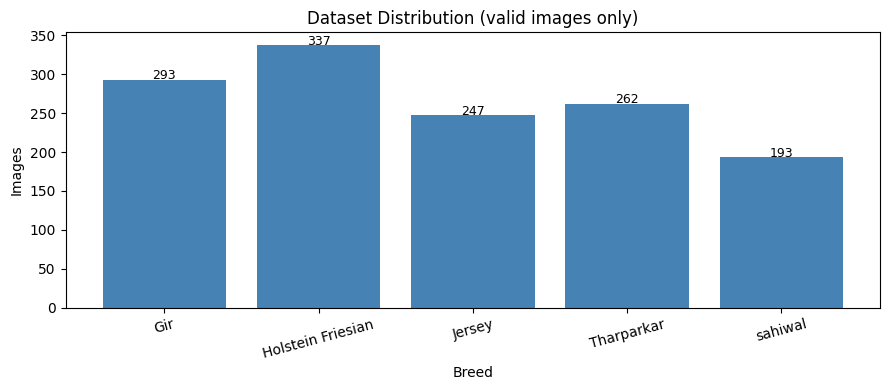

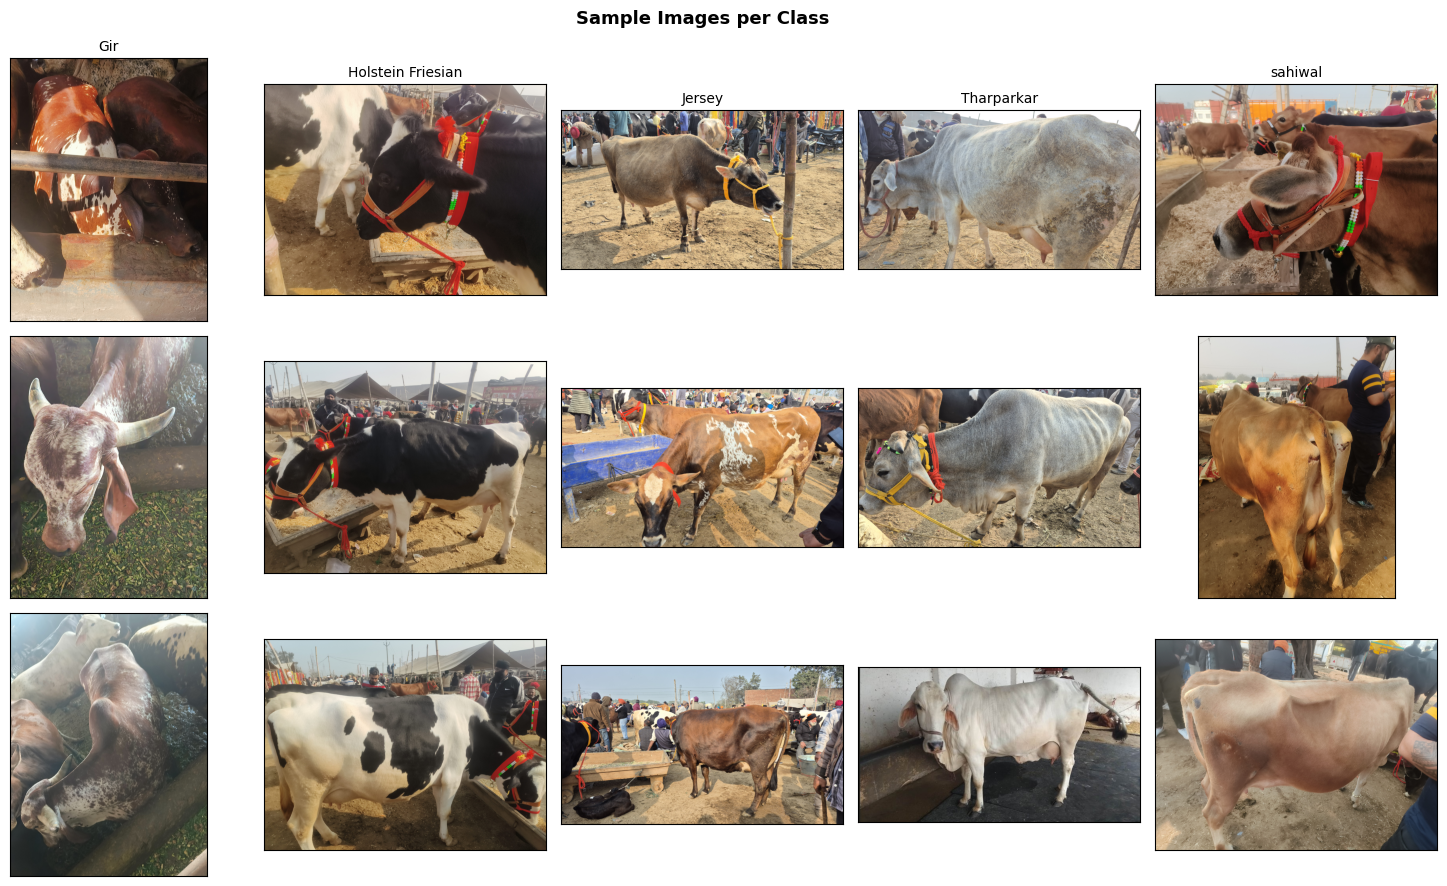

In [7]:
# ══════════════════════════════════════════════════
# CELL 4 — Dataset Exploration
# ══════════════════════════════════════════════════
from PIL import Image as PILImage

def is_valid_image(path):
    """Return True only if the image file can be opened and verified."""
    try:
        with PILImage.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

class_counts = {}
bad_files    = []

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    valid = []
    for fname in all_imgs:
        fpath = os.path.join(cls_path, fname)
        if is_valid_image(fpath):
            valid.append(fname)
        else:
            bad_files.append(fpath)
    class_counts[cls] = len(valid)

print('Classes and valid image counts:')
for k, v in class_counts.items():
    print(f'  {k}: {v} images')
print(f'  TOTAL: {sum(class_counts.values())} valid images')
if bad_files:
    print(f'\n⚠️  Skipped {len(bad_files)} unreadable file(s):')
    for bf in bad_files[:10]:
        print(f'   {bf}')

# ── Bar chart ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, str(val), ha='center', fontsize=9)
plt.title('Dataset Distribution (valid images only)')
plt.xlabel('Breed'); plt.ylabel('Images')
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_distribution.png'), dpi=120)
plt.show()

# ── Sample grid ────────────────────────────────────────────────────────────────
n_rows, n_cols = 3, NUM_CLASSES
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
if n_cols == 1:
    axes = np.array(axes).reshape(-1, 1)

for col, cls in enumerate(class_names):
    cls_dir   = os.path.join(DATA_DIR, cls)
    all_imgs  = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    valid_imgs = []
    for fname in all_imgs:
        if is_valid_image(os.path.join(cls_dir, fname)):
            valid_imgs.append(fname)
        if len(valid_imgs) >= n_rows:
            break
    for row in range(n_rows):
        ax = axes[row][col]
        if row < len(valid_imgs):
            try:
                ax.imshow(
                    PILImage.open(os.path.join(cls_dir, valid_imgs[row])).convert('RGB'))
            except Exception:
                ax.text(0.5, 0.5, 'unreadable', ha='center', va='center',
                        transform=ax.transAxes, color='red')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(cls, fontsize=10)
plt.suptitle('Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=120)
plt.show()


╔═══════════════════════════════════════════════════════════════════╗
║                  TRAIN / VALIDATION SPLIT SUMMARY                   ║
╠═══════════════════════════════════════════════════════════════════╣
║  Total images             1332  (100.0%)                            ║
║  Training images          1065  (80.0%)                             ║
║  Validation images         267  (20.0%)                             ║
╠═══════════════════════════════════════════════════════════════════╣
║  Class                  Train     Val   Total   Train%     Val%  ║
╠───────────────────────────────────────────────────────────────────╣
║  Gir                      232      61     293    79.2%    20.8%  ║
║  Holstein Friesian        269      68     337    79.8%    20.2%  ║
║  Jersey                   206      41     247    83.4%    16.6%  ║
║  Tharparkar               209      53     262    79.8%    20.2%  ║
║  sahiwal                  149      44     193    77.2%    22.8%  ║
╠─────────────────

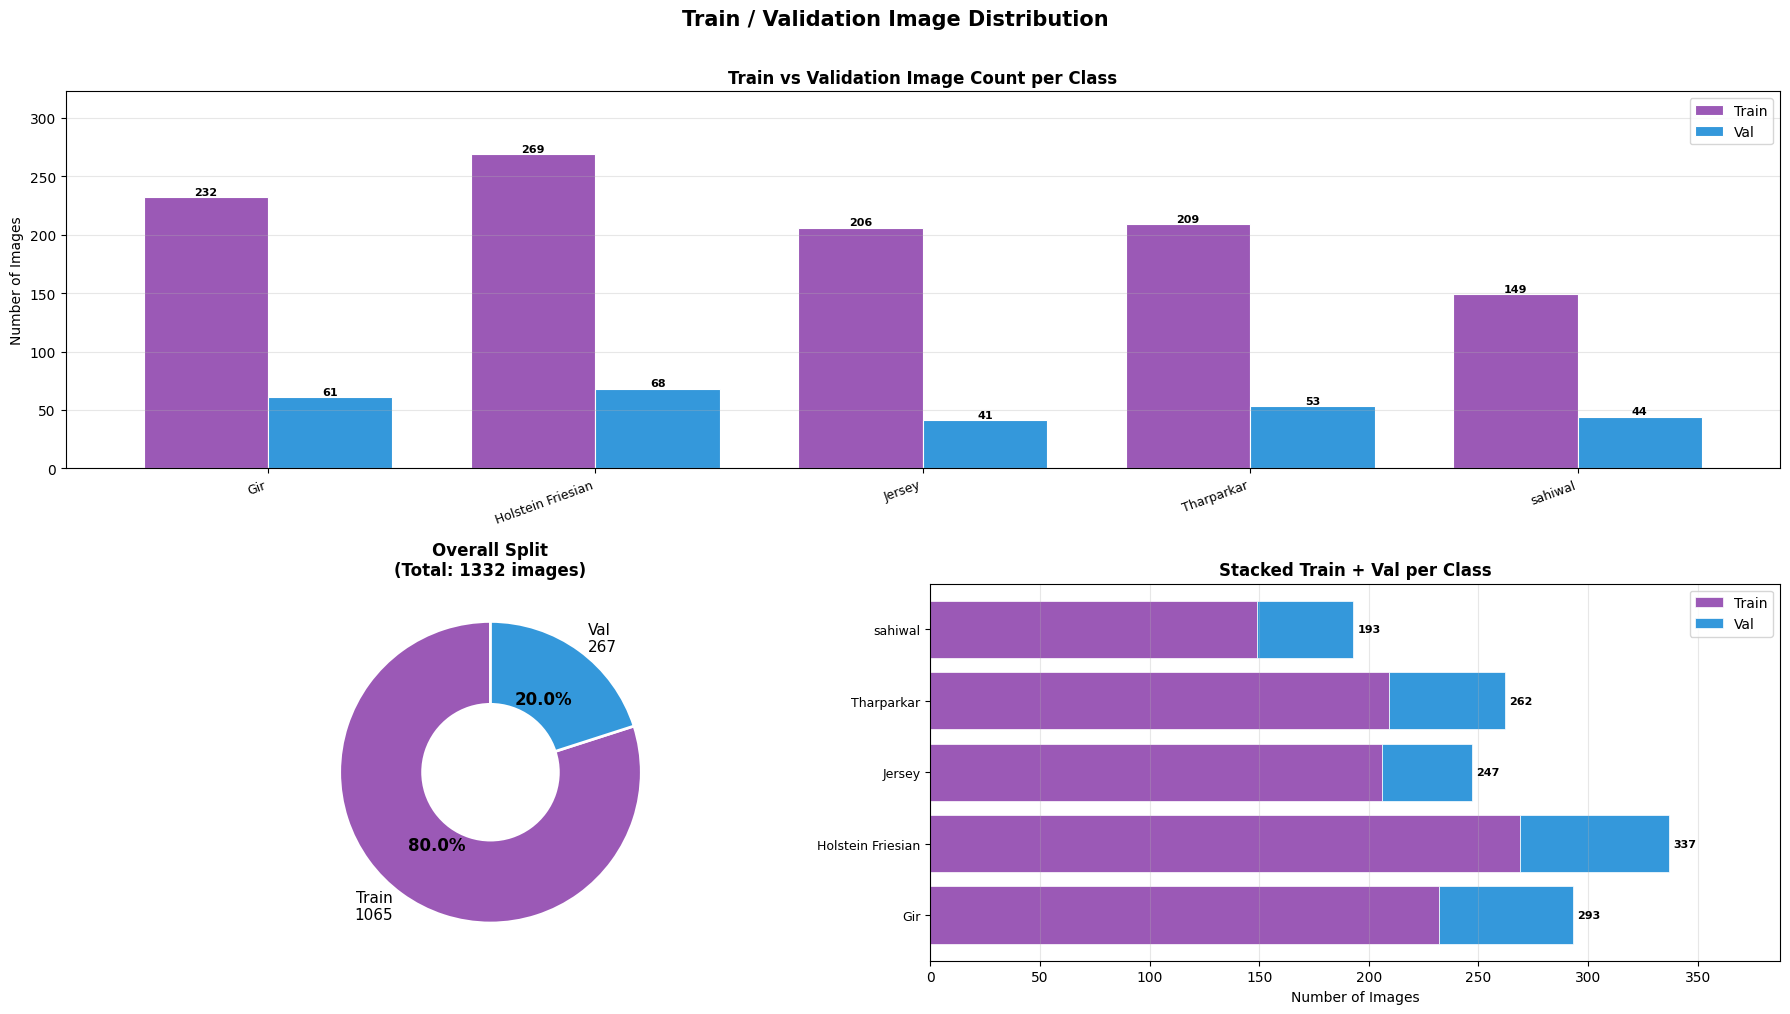


✅ Figure saved to output folder.


In [8]:
# ══════════════════════════════════════════════════
# CELL 4B — Train / Validation Split Summary
# ══════════════════════════════════════════════════
import random as _random

all_samples = []
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_samples.append((os.path.join(cls_dir, fname), cls))

_random.seed(SEED)
_random.shuffle(all_samples)
split_point = int(len(all_samples) * (1 - VAL_SPLIT))

train_samples = all_samples[:split_point]
val_samples   = all_samples[split_point:]

train_counts = {cls: 0 for cls in class_names}
val_counts   = {cls: 0 for cls in class_names}
for _, cls in train_samples:
    train_counts[cls] += 1
for _, cls in val_samples:
    val_counts[cls]   += 1

total_train = len(train_samples)
total_val   = len(val_samples)
total_all   = total_train + total_val

# ── Text table ────────────────────────────────────────────────────────────────
print('╔' + '═' * 67 + '╗')
print(f'║  {"TRAIN / VALIDATION SPLIT SUMMARY":^65}  ║')
print('╠' + '═' * 67 + '╣')
print(f'║  {"Total images":<22} {total_all:>6}  (100.0%)' + ' '*28 + '║')
print(f'║  {"Training images":<22} {total_train:>6}  ({total_train/total_all*100:.1f}%)' + ' '*29 + '║')
print(f'║  {"Validation images":<22} {total_val:>6}  ({total_val/total_all*100:.1f}%)' + ' '*29 + '║')
print('╠' + '═' * 67 + '╣')
print(f'║  {"Class":<20}  {"Train":>6}  {"Val":>6}  {"Total":>6}  {"Train%":>7}  {"Val%":>7}  ║')
print('╠' + '─' * 67 + '╣')
for cls in class_names:
    tr = train_counts[cls]; va = val_counts[cls]; tot = tr + va
    pct_tr = tr / tot * 100 if tot > 0 else 0
    pct_va = va / tot * 100 if tot > 0 else 0
    print(f'║  {cls:<20}  {tr:>6}  {va:>6}  {tot:>6}  {pct_tr:>6.1f}%  {pct_va:>6.1f}%  ║')
print('╠' + '─' * 67 + '╣')
print(f'║  {"TOTAL":<20}  {total_train:>6}  {total_val:>6}  {total_all:>6}  {total_train/total_all*100:>6.1f}%  {total_val/total_all*100:>6.1f}%  ║')
print('╚' + '═' * 67 + '╝')

# ── Visual breakdown ──────────────────────────────────────────────────────────
TRAIN_COLOR = '#9b59b6'
VAL_COLOR   = '#3498db'
x     = np.arange(len(class_names))
bar_w = 0.38

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Train / Validation Image Distribution', fontsize=15, fontweight='bold', y=1.01)

# Grouped bar
ax1 = fig.add_subplot(2, 2, (1, 2))
b1 = ax1.bar(x - bar_w/2, [train_counts[c] for c in class_names],
             bar_w, label='Train', color=TRAIN_COLOR, edgecolor='white', linewidth=0.8)
b2 = ax1.bar(x + bar_w/2, [val_counts[c]   for c in class_names],
             bar_w, label='Val',   color=VAL_COLOR,   edgecolor='white', linewidth=0.8)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_title('Train vs Validation Image Count per Class', fontsize=12, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(class_names, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Number of Images'); ax1.legend(fontsize=10); ax1.grid(axis='y', alpha=0.3)
max_val = max(max(train_counts.values()), max(val_counts.values()))
ax1.set_ylim(0, max_val * 1.2)

# Donut
ax2 = fig.add_subplot(2, 2, 3)
wedges, texts, autotexts = ax2.pie(
    [total_train, total_val],
    labels=[f'Train\n{total_train}', f'Val\n{total_val}'],
    colors=[TRAIN_COLOR, VAL_COLOR],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
ax2.set_title(f'Overall Split\n(Total: {total_all} images)', fontsize=12, fontweight='bold')

# Stacked horizontal bar
ax3 = fig.add_subplot(2, 2, 4)
train_vals = [train_counts[c] for c in class_names]
val_vals   = [val_counts[c]   for c in class_names]
y_pos      = np.arange(len(class_names))
ax3.barh(y_pos, train_vals, color=TRAIN_COLOR, label='Train', edgecolor='white', linewidth=0.5)
ax3.barh(y_pos, val_vals, left=train_vals, color=VAL_COLOR, label='Val',
         edgecolor='white', linewidth=0.5)
for i, cls in enumerate(class_names):
    tot = train_counts[cls] + val_counts[cls]
    ax3.text(tot + 2, i, str(tot), va='center', fontsize=8, fontweight='bold')
ax3.set_yticks(y_pos); ax3.set_yticklabels(class_names, fontsize=9)
ax3.set_xlabel('Number of Images')
ax3.set_title('Stacked Train + Val per Class', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(axis='x', alpha=0.3)
max_stacked = max(train_counts[c] + val_counts[c] for c in class_names)
ax3.set_xlim(0, max_stacked * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'train_val_split.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Figure saved to output folder.')


## Model 1 — EfficientNetB0
> Transfer learning with `preprocess_input` — two-phase training

EfficientNetB0
Found 1068 images belonging to 5 classes.
Found 264 images belonging to 5 classes.
Class weights:
  [0] Gir: 0.909
  [1] Holstein Friesian: 0.791
  [2] Jersey: 1.079
  [3] Tharparkar: 1.017
  [4] sahiwal: 1.378
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 254s 12s/step - accuracy: 0.4345 - loss: 1.8599 - val_accuracy: 0.5303 - val_loss: 1.4224 - learning_rate: 0.0010
Epoch 2/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.6498 - loss: 1.3751 - val_accuracy: 0.5492 - val_loss: 1.3685 - learning_rate: 0.0010
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.6994 - loss: 1.2473 - val_accuracy: 0.5114 - val_loss: 1.3924 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 236s 10s/step - accuracy: 0.6891 - loss: 1.2931 - val_accuracy: 0.5568 - val_loss: 1.3398
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.7097 - loss: 1.2350 - v

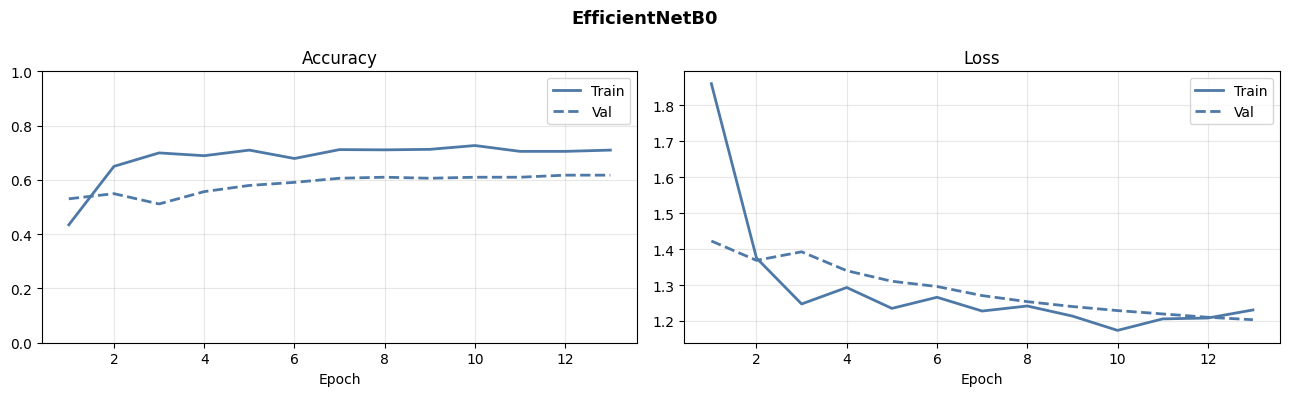

  Saved: EfficientNetB0_history.png
EfficientNetB0 — Val Accuracy: 61.74%  Loss: 1.2103
                   precision    recall  f1-score   support

              Gir       0.83      0.33      0.47        58
Holstein Friesian       0.86      0.93      0.89        67
           Jersey       0.55      0.12      0.20        49
       Tharparkar       0.82      0.87      0.84        52
          sahiwal       0.30      0.82      0.44        38

         accuracy                           0.62       264
        macro avg       0.67      0.61      0.57       264
     weighted avg       0.71      0.62      0.60       264



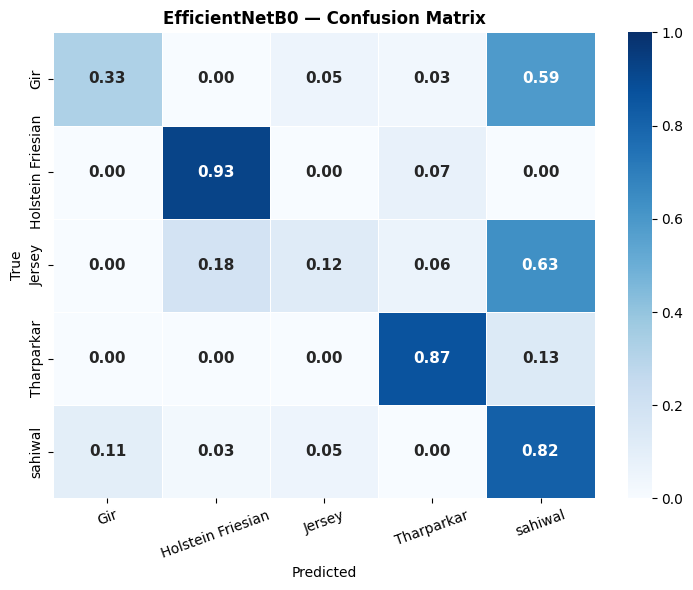

✅ EfficientNetB0 saved — 61.74%


In [10]:
# ══════════════════════════════════════════════════
# CELL 5 — EfficientNetB0
# Phase 1: warm-up frozen backbone  (3 epochs, lr=1e-3)
# Phase 2: fine-tune last 80 layers (10 epochs, cosine LR)
# ══════════════════════════════════════════════════
print('=' * 55)
print('EfficientNetB0')
print('=' * 55)

eff_preprocess = tf.keras.applications.efficientnet.preprocess_input
eff_train, eff_val = get_generators(use_preprocess_fn=eff_preprocess)
cw_eff = get_class_weights(eff_train)

def build_efficientnet(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = tf.keras.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.55)(x)
    x   = layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.45)(x)
    x   = layers.Activation('linear', dtype='float32')(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inp, out), base

eff_model, eff_base = build_efficientnet(NUM_CLASSES)

# ── Phase 1: warm-up ──────────────────────────────────────────────────────────
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h1_eff = eff_model.fit(
    eff_train, validation_data=eff_val,
    epochs=EPOCHS_WARMUP, class_weight=cw_eff,
    callbacks=get_callbacks('eff_p1', patience_es=5, use_reduce_lr=True),
    verbose=1)

# ── Phase 2: fine-tune last 80 layers ────────────────────────────────────────
eff_base.trainable = True
for i, layer in enumerate(eff_base.layers):
    layer.trainable = (i >= len(eff_base.layers) - 80)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

total_steps = len(eff_train) * EPOCHS_FINETUNE
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=total_steps, alpha=1e-7)

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h2_eff = eff_model.fit(
    eff_train, validation_data=eff_val,
    epochs=EPOCHS_FINETUNE, class_weight=cw_eff,
    callbacks=get_callbacks('eff_p2', patience_es=5, use_reduce_lr=False),
    verbose=1)

# ── Evaluate & save ───────────────────────────────────────────────────────────
eff_hist = MergedHistory(h1_eff, h2_eff)
plot_history(eff_hist, 'EfficientNetB0', '#4e79a7')
acc, loss, yp, yt, lbls = evaluate_model(eff_model, eff_val, 'EfficientNetB0')
plot_confusion(yt, yp, lbls, 'EfficientNetB0')
all_results['EfficientNetB0'] = round(acc * 100, 2)
save_path = os.path.join(OUTPUT_DIR, 'EfficientNetB0.keras')
eff_model.save(save_path)
print(f"✅ EfficientNetB0 saved — {all_results['EfficientNetB0']}%")

## Model 2 — MobileNetV2
> Transfer learning — two-phase training

MobileNetV2
Found 1068 images belonging to 5 classes.
Found 264 images belonging to 5 classes.
Class weights:
  [0] Gir: 0.909
  [1] Holstein Friesian: 0.791
  [2] Jersey: 1.079
  [3] Tharparkar: 1.017
  [4] sahiwal: 1.378
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 163s 8s/step - accuracy: 0.4607 - loss: 1.9132 - val_accuracy: 0.5568 - val_loss: 1.2968 - learning_rate: 0.0010
Epoch 2/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.6058 - loss: 1.5181 - val_accuracy: 0.5758 - val_loss: 1.2627 - learning_rate: 0.0010
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6742 - loss: 1.2478 - val_accuracy: 0.6023 - val_loss: 1.2587 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 176s 8s/step - accuracy: 0.6863 - loss: 1.2195 - val_accuracy: 0.6061 - val_loss: 1.2639
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.6751 - loss: 1.2287 - val_accu

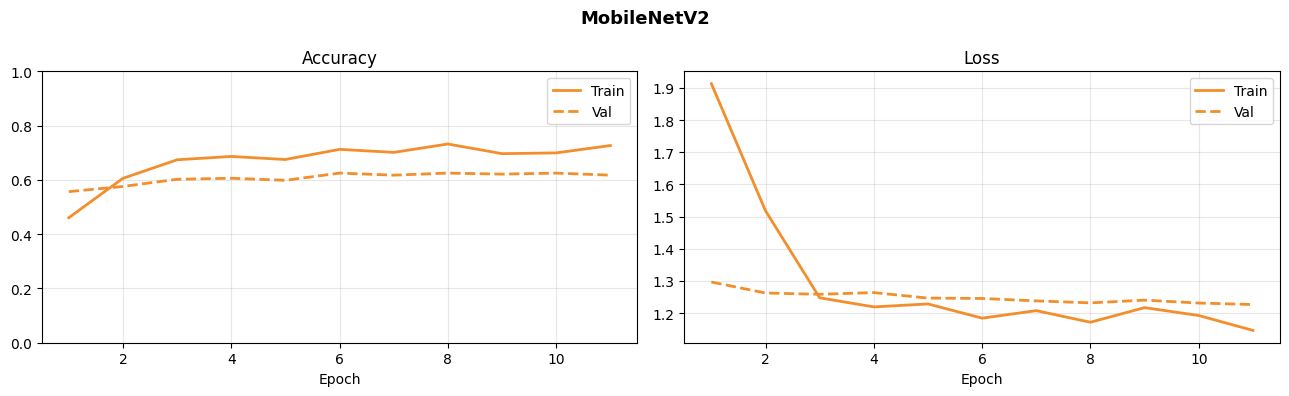

  Saved: MobileNetV2_history.png
MobileNetV2 — Val Accuracy: 62.50%  Loss: 1.2457
                   precision    recall  f1-score   support

              Gir       0.81      0.43      0.56        58
Holstein Friesian       0.82      0.91      0.87        67
           Jersey       0.53      0.16      0.25        49
       Tharparkar       0.82      0.77      0.79        52
          sahiwal       0.33      0.82      0.47        38

         accuracy                           0.62       264
        macro avg       0.66      0.62      0.59       264
     weighted avg       0.69      0.62      0.61       264



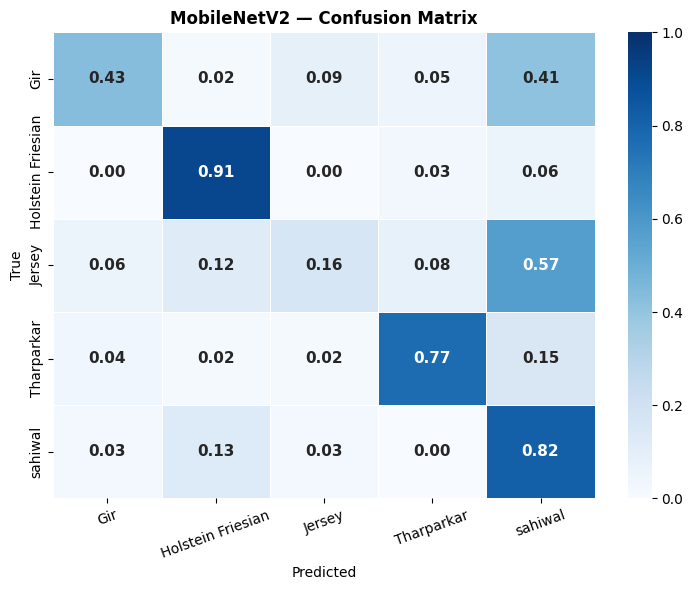

✅ MobileNetV2 saved — 62.5%


In [12]:
# ══════════════════════════════════════════════════
# CELL 6 — MobileNetV2
# Phase 1: warm-up frozen backbone  (3 epochs, lr=1e-3)
# Phase 2: fine-tune last 50 layers (10 epochs, cosine LR)
# ══════════════════════════════════════════════════
print('=' * 55)
print('MobileNetV2')
print('=' * 55)

mob_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
mob_train, mob_val = get_generators(use_preprocess_fn=mob_preprocess)
cw_mob = get_class_weights(mob_train)

def build_mobilenet(num_classes):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = tf.keras.Input(shape=(224, 224, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.55)(x)
    x   = layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.45)(x)
    x   = layers.Activation('linear', dtype='float32')(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inp, out), base

mob_model, mob_base = build_mobilenet(NUM_CLASSES)

# ── Phase 1: warm-up ──────────────────────────────────────────────────────────
mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h1_mob = mob_model.fit(
    mob_train, validation_data=mob_val,
    epochs=EPOCHS_WARMUP, class_weight=cw_mob,
    callbacks=get_callbacks('mob_p1', patience_es=5, use_reduce_lr=True),
    verbose=1)

# ── Phase 2: fine-tune last 50 layers ────────────────────────────────────────
mob_base.trainable = True
for i, layer in enumerate(mob_base.layers):
    layer.trainable = (i >= len(mob_base.layers) - 50)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

total_steps = len(mob_train) * EPOCHS_FINETUNE
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=total_steps, alpha=1e-7)

mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h2_mob = mob_model.fit(
    mob_train, validation_data=mob_val,
    epochs=EPOCHS_FINETUNE, class_weight=cw_mob,
    callbacks=get_callbacks('mob_p2', patience_es=5, use_reduce_lr=False),
    verbose=1)

# ── Evaluate & save ───────────────────────────────────────────────────────────
mob_hist = MergedHistory(h1_mob, h2_mob)
plot_history(mob_hist, 'MobileNetV2', '#f28e2b')
acc, loss, yp, yt, lbls = evaluate_model(mob_model, mob_val, 'MobileNetV2')
plot_confusion(yt, yp, lbls, 'MobileNetV2')
all_results['MobileNetV2'] = round(acc * 100, 2)
save_path = os.path.join(OUTPUT_DIR, 'MobileNetV2.keras')
mob_model.save(save_path)
print(f"✅ MobileNetV2 saved — {all_results['MobileNetV2']}%")

## Model 3 — ResNet50
> Transfer learning — two-phase training

ResNet50
Found 1068 images belonging to 5 classes.
Found 264 images belonging to 5 classes.
Class weights:
  [0] Gir: 0.909
  [1] Holstein Friesian: 0.791
  [2] Jersey: 1.079
  [3] Tharparkar: 1.017
  [4] sahiwal: 1.378
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.4897 - loss: 1.9110 - val_accuracy: 0.6212 - val_loss: 1.3844 - learning_rate: 0.0010
Epoch 2/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.6517 - loss: 1.4039 - val_accuracy: 0.6326 - val_loss: 1.2072 - learning_rate: 0.0010
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.6929 - loss: 1.2392 - val_accuracy: 0.6288 - val_loss: 1.2046 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.6891 - loss: 1.2734 - val_accuracy: 0.6364 - val_loss: 1.2077
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.6976 - loss: 1.2673 - val_accur

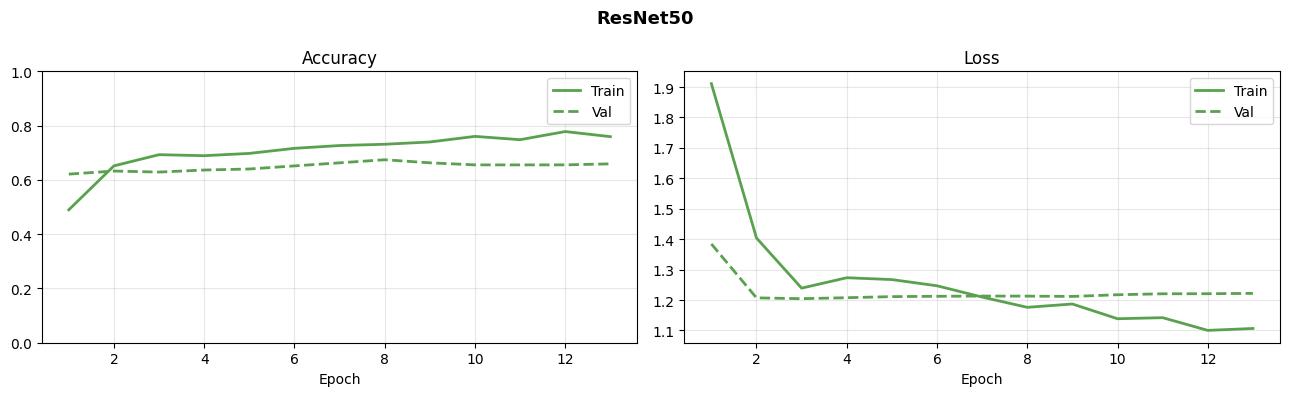

  Saved: ResNet50_history.png
ResNet50 — Val Accuracy: 67.42%  Loss: 1.2129


                   precision    recall  f1-score   support

              Gir       0.64      0.67      0.66        58
Holstein Friesian       0.79      0.93      0.86        67
           Jersey       0.58      0.29      0.38        49
       Tharparkar       0.80      0.87      0.83        52
          sahiwal       0.40      0.47      0.43        38

         accuracy                           0.67       264
        macro avg       0.64      0.64      0.63       264
     weighted avg       0.67      0.67      0.66       264



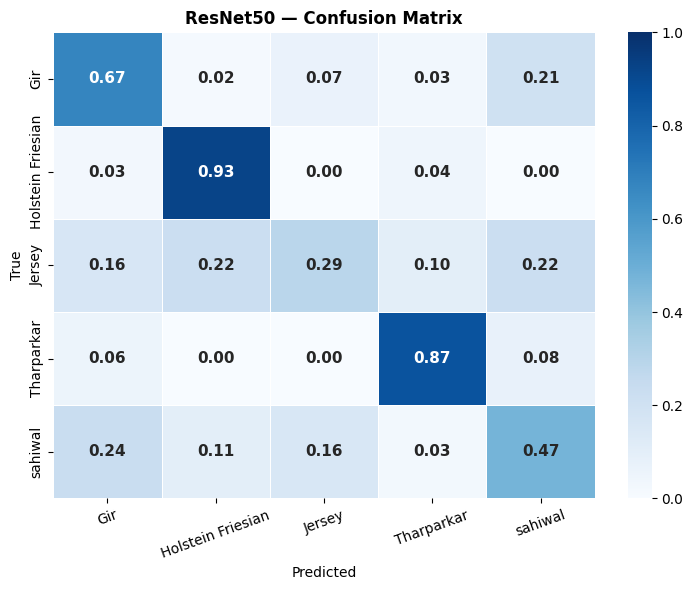

✅ ResNet50 saved — 67.42%


In [14]:
# ══════════════════════════════════════════════════
# CELL 7 — ResNet50
# Phase 1: warm-up frozen backbone  (3 epochs, lr=1e-3)
# Phase 2: fine-tune last 50 layers (10 epochs, cosine LR)
# ══════════════════════════════════════════════════
print('=' * 55)
print('ResNet50')
print('=' * 55)

from tensorflow.keras.applications import ResNet50 as _ResNet50
from tensorflow.keras import Model as KModel

res_preprocess = tf.keras.applications.resnet50.preprocess_input
res_train, res_val = get_generators(use_preprocess_fn=res_preprocess)
cw_res = get_class_weights(res_train)

def build_resnet(num_classes):
    inp  = tf.keras.Input(shape=(224, 224, 3))
    base = _ResNet50(weights='imagenet', include_top=False,
                     input_tensor=inp)
    base.trainable = False
    x   = base.output
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(2e-4))(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Activation('linear', dtype='float32')(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = KModel(inputs=base.input, outputs=out)
    return model, base

res_model, res_base = build_resnet(NUM_CLASSES)

# ── Phase 1: warm-up ──────────────────────────────────────────────────────────
res_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h1_res = res_model.fit(
    res_train, validation_data=res_val,
    epochs=EPOCHS_WARMUP, class_weight=cw_res,
    callbacks=get_callbacks('res_p1', patience_es=5, use_reduce_lr=True),
    verbose=1)

# ── Phase 2: fine-tune last 50 layers ────────────────────────────────────────
res_base.trainable = True
for i, layer in enumerate(res_base.layers):
    layer.trainable = (i >= len(res_base.layers) - 50)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

total_steps = len(res_train) * EPOCHS_FINETUNE
cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=total_steps, alpha=1e-7)

res_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

h2_res = res_model.fit(
    res_train, validation_data=res_val,
    epochs=EPOCHS_FINETUNE, class_weight=cw_res,
    callbacks=get_callbacks('res_p2', patience_es=5, use_reduce_lr=False),
    verbose=1)

# ── Evaluate & save ───────────────────────────────────────────────────────────
res_hist = MergedHistory(h1_res, h2_res)
plot_history(res_hist, 'ResNet50', '#59a14f')
acc, loss, yp, yt, lbls = evaluate_model(res_model, res_val, 'ResNet50')
plot_confusion(yt, yp, lbls, 'ResNet50')
all_results['ResNet50'] = round(acc * 100, 2)
save_path = os.path.join(OUTPUT_DIR, 'ResNet50.keras')
res_model.save(save_path)
print(f"✅ ResNet50 saved — {all_results['ResNet50']}%")

## Model 4 — CNN from Scratch
> Deep custom CNN — single phase, full training

CNN from Scratch
Found 1068 images belonging to 5 classes.
Found 264 images belonging to 5 classes.
Class weights:
  [0] Gir: 0.909
  [1] Holstein Friesian: 0.791
  [2] Jersey: 1.079
  [3] Tharparkar: 1.017
  [4] sahiwal: 1.378
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 209s 7s/step - accuracy: 0.2903 - loss: 2.4803 - val_accuracy: 0.2008 - val_loss: 1.7496
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.3605 - loss: 2.2041 - val_accuracy: 0.1970 - val_loss: 1.8771
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.3708 - loss: 2.1658 - val_accuracy: 0.1970 - val_loss: 1.7876
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.4448 - loss: 1.9821 - val_accuracy: 0.1856 - val_loss: 1.7699
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.4242 - loss: 1.9034 - val_accuracy: 0.1477 - val_loss: 1.9265
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.4513 - loss: 1.7881 - val_accuracy: 0.1970 - val_loss: 1.8424
Epoch 6: early 

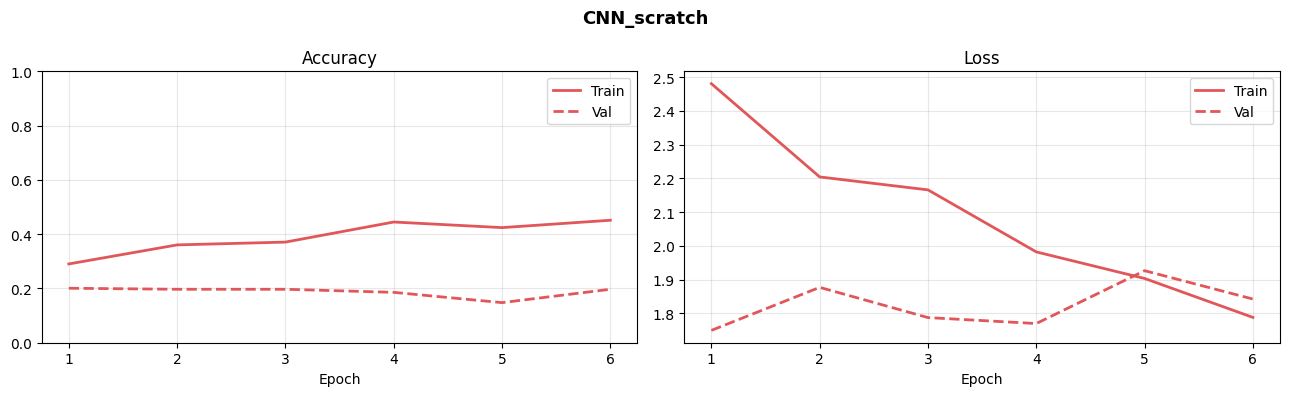

  Saved: CNN_scratch_history.png
CNN_scratch — Val Accuracy: 20.08%  Loss: 1.7496
                   precision    recall  f1-score   support

              Gir       0.00      0.00      0.00        58
Holstein Friesian       0.00      0.00      0.00        67
           Jersey       1.00      0.02      0.04        49
       Tharparkar       0.20      1.00      0.33        52
          sahiwal       0.00      0.00      0.00        38

         accuracy                           0.20       264
        macro avg       0.24      0.20      0.07       264
     weighted avg       0.22      0.20      0.07       264



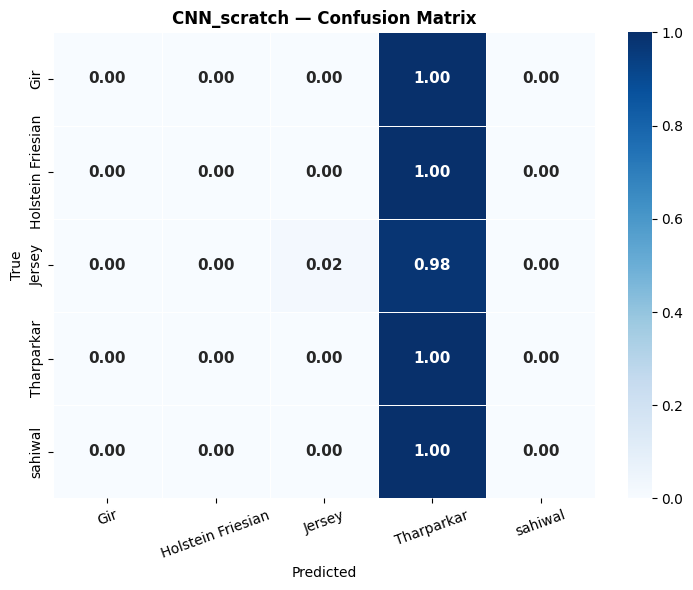

✅ CNN_scratch saved — 20.08%


In [16]:
# ══════════════════════════════════════════════════
# CELL 8 — CNN from Scratch
# Single phase — cosine LR decay
# ══════════════════════════════════════════════════
print('=' * 55)
print('CNN from Scratch')
print('=' * 55)

cnn_train, cnn_val = get_generators(use_preprocess_fn=None)
cw_cnn = get_class_weights(cnn_train)

def build_cnn_scratch(num_classes):
    inp = tf.keras.Input(shape=(224, 224, 3))

    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Dropout(0.3)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.55)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.45)(x)
    x   = layers.Activation('linear', dtype='float32')(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inp, out)

cnn_model = build_cnn_scratch(NUM_CLASSES)

total_steps = len(cnn_train) * EPOCHS_FINETUNE
cnn_lr = tf.keras.optimizers.schedules.CosineDecay(1e-3, total_steps, alpha=1e-7)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cnn_lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy'])

hist_cnn = cnn_model.fit(
    cnn_train, validation_data=cnn_val,
    epochs=EPOCHS_FINETUNE, class_weight=cw_cnn,
    callbacks=get_callbacks('cnn_scratch', patience_es=5, use_reduce_lr=False),
    verbose=1)

# ── Evaluate & save ───────────────────────────────────────────────────────────
plot_history(hist_cnn, 'CNN_scratch', '#e15759')
acc, loss, yp, yt, lbls = evaluate_model(cnn_model, cnn_val, 'CNN_scratch')
plot_confusion(yt, yp, lbls, 'CNN_scratch')
all_results['CNN_scratch'] = round(acc * 100, 2)
save_path = os.path.join(OUTPUT_DIR, 'CNN_scratch.keras')
cnn_model.save(save_path)
print(f"✅ CNN_scratch saved — {all_results['CNN_scratch']}%")

## Model 5 — Vision Transformer (ViT)
> PyTorch + timm — `vit_base_patch16_224` pretrained

In [17]:
# ══════════════════════════════════════════════════
# CELL 9 — ViT Setup (timm + PyTorch)
# ══════════════════════════════════════════════════
import timm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image as PILImage

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 2   # 0 if you hit DataLoader issues in Colab
print(f'timm: {timm.__version__}  |  torch: {torch.__version__}  |  device: {device}')

class_to_idx = {cls: i for i, cls in enumerate(class_names)}

# ── Dataset class ──────────────────────────────────────────────────────────────
class CattleDataset(Dataset):
    def __init__(self, data_dir, class_to_idx, transform=None,
                 split='train', val_split=0.2, seed=42):
        all_samples = []
        for cls, idx in class_to_idx.items():
            cls_dir = os.path.join(data_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_samples.append((os.path.join(cls_dir, fname), idx))
        random.seed(seed)
        random.shuffle(all_samples)
        sp = int(len(all_samples) * (1 - val_split))
        self.samples   = all_samples[:sp] if split == 'train' else all_samples[sp:]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        try:
            img = PILImage.open(path).convert('RGB')
        except Exception:
            # Return a blank image if file is corrupt
            img = PILImage.new('RGB', (224, 224), color=0)
        if self.transform:
            img = self.transform(img)
        return img, label

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

vit_train_ds = CattleDataset(DATA_DIR, class_to_idx, aug_transform, split='train')
vit_val_ds   = CattleDataset(DATA_DIR, class_to_idx, val_transform,  split='val')

# Use persistent_workers only if NUM_WORKERS > 0
_pw = NUM_WORKERS > 0
vit_train_dl = DataLoader(vit_train_ds, batch_size=16, shuffle=True,
                           num_workers=NUM_WORKERS, persistent_workers=_pw,
                           pin_memory=(device.type == 'cuda'))
vit_val_dl   = DataLoader(vit_val_ds,   batch_size=16, shuffle=False,
                           num_workers=NUM_WORKERS, persistent_workers=_pw,
                           pin_memory=(device.type == 'cuda'))
print(f'Train: {len(vit_train_ds)}  |  Val: {len(vit_val_ds)}')

# ── Training loop ──────────────────────────────────────────────────────────────
def train_vit_phase(model, train_dl, val_dl, epochs, lr, tag, patience=10):
    """
    Two param groups: backbone at lr, head at lr*10.
    Cosine annealing + label smoothing + early stopping.
    """
    head_ids = set(id(p) for p in model.head.parameters())
    param_groups = [
        {'params': [p for p in model.parameters()
                    if id(p) not in head_ids and p.requires_grad], 'lr': lr},
        {'params': list(model.head.parameters()), 'lr': lr * 10},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-8)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc, no_improve = 0.0, 0
    best_ckpt = os.path.join(OUTPUT_DIR, f'best_vit_{tag}.pth')
    hist = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        tr_loss, tr_corr, n = 0.0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            tr_loss += loss.item()
            tr_corr += (out.argmax(1) == labels).sum().item()
            n       += labels.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_corr, vn = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out     = model(imgs)
                v_loss += criterion(out, labels).item()
                v_corr += (out.argmax(1) == labels).sum().item()
                vn     += labels.size(0)

        t_acc = tr_corr / n if n > 0 else 0.0
        v_acc = v_corr  / vn if vn > 0 else 0.0
        hist['train_acc'].append(t_acc)
        hist['val_acc'].append(v_acc)
        hist['train_loss'].append(tr_loss / max(len(train_dl), 1))
        hist['val_loss'].append(v_loss   / max(len(val_dl),   1))

        cur_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1:>3}/{epochs} | '
              f'train {t_acc:.4f} | val {v_acc:.4f} | lr {cur_lr:.2e}')

        if v_acc > best_acc:
            best_acc = v_acc; no_improve = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        scheduler.step()

    # Restore best weights
    if os.path.exists(best_ckpt):
        model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print(f'Best val accuracy ({tag}): {best_acc*100:.2f}%')
    return hist, best_acc

# ── ViT history plot ───────────────────────────────────────────────────────────
def plot_vit_history(hist, color='#9b59b6'):
    ep = range(1, len(hist['train_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('ViT (vit_base_patch16_224)', fontsize=13, fontweight='bold')
    axes[0].plot(ep, hist['train_acc'], lw=2, color=color, label='Train')
    axes[0].plot(ep, hist['val_acc'],   lw=2, color=color, ls='--', label='Val')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylim=[0, 1])
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, hist['train_loss'], lw=2, color=color, label='Train')
    axes[1].plot(ep, hist['val_loss'],   lw=2, color=color, ls='--', label='Val')
    axes[1].set(title='Loss', xlabel='Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ViT_history.png', dpi=120)
    save_to_output('ViT_history.png')
    plt.show()

print('✅ ViT utilities ready.')


timm: 1.0.26  |  torch: 2.10.0+cu128  |  device: cuda
Train: 1065  |  Val: 267
✅ ViT utilities ready.


ViT — vit_base_patch16_224 (pretrained)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


--- Phase 1: head warm-up ---
Epoch   1/3 | train 0.7155 | val 0.8015 | lr 5.00e-04
Epoch   2/3 | train 0.7915 | val 0.8202 | lr 3.75e-04
Epoch   3/3 | train 0.8770 | val 0.8165 | lr 1.25e-04
Best val accuracy (p1): 82.02%
Phase 2 trainable params: 42,532,613

--- Phase 2: fine-tune ---
Epoch   1/10 | train 0.8066 | val 0.8277 | lr 5.00e-05
Epoch   2/10 | train 0.8817 | val 0.8764 | lr 4.88e-05
Epoch   3/10 | train 0.9427 | val 0.8764 | lr 4.52e-05
Epoch   4/10 | train 0.9653 | val 0.8652 | lr 3.97e-05
Epoch   5/10 | train 0.9793 | val 0.8951 | lr 3.27e-05
Epoch   6/10 | train 0.9897 | val 0.8727 | lr 2.50e-05
Epoch   7/10 | train 0.9934 | val 0.8801 | lr 1.73e-05
Epoch   8/10 | train 0.9962 | val 0.8689 | lr 1.03e-05
Epoch   9/10 | train 0.9991 | val 0.8839 | lr 4.78e-06
Epoch  10/10 | train 0.9981 | val 0.8727 | lr 1.23e-06
Best val accuracy (p2): 89.51%


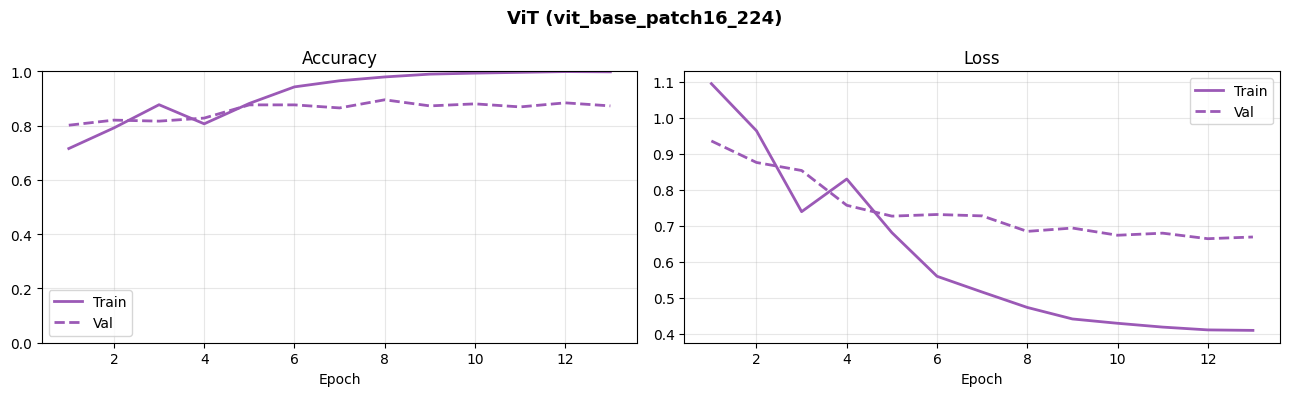

                   precision    recall  f1-score   support

              Gir       0.89      0.92      0.90        61
Holstein Friesian       0.96      0.99      0.97        68
           Jersey       0.81      0.83      0.82        41
       Tharparkar       0.98      0.96      0.97        53
          sahiwal       0.78      0.70      0.74        44

         accuracy                           0.90       267
        macro avg       0.88      0.88      0.88       267
     weighted avg       0.89      0.90      0.89       267



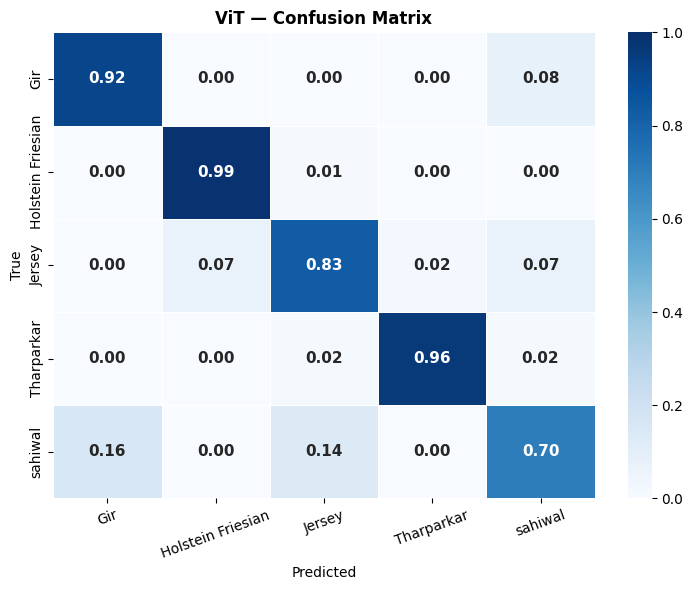

✅ ViT saved — 89.51%


In [18]:
# ══════════════════════════════════════════════════
# CELL 10 — ViT Training
# Phase 1: head only       — 10 epochs, lr=5e-4
# Phase 2: last 6 blocks + norm + head — 40 epochs, lr=5e-5
# ══════════════════════════════════════════════════
print('=' * 55)
print('ViT — vit_base_patch16_224 (pretrained)')
print('=' * 55)

vit_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

# ── Phase 1: head only ────────────────────────────────────────────────────────
for p in vit_model.parameters():
    p.requires_grad = False
for p in vit_model.head.parameters():
    p.requires_grad = True

print('\n--- Phase 1: head warm-up ---')
h1_vit, _ = train_vit_phase(
    vit_model, vit_train_dl, vit_val_dl,
    epochs=3, lr=5e-4, tag='p1', patience=5)  # ⚡ FAST MODE: reduced from 10

# ── Phase 2: last 6 transformer blocks + norm + head ─────────────────────────
for p in vit_model.parameters():
    p.requires_grad = False

total_blocks = len(vit_model.blocks)
for i in range(total_blocks - 6, total_blocks):
    for p in vit_model.blocks[i].parameters():
        p.requires_grad = True
for p in vit_model.norm.parameters():
    p.requires_grad = True
for p in vit_model.head.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'Phase 2 trainable params: {trainable:,}')

print('\n--- Phase 2: fine-tune ---')
h2_vit, vit_best = train_vit_phase(
    vit_model, vit_train_dl, vit_val_dl,
    epochs=10, lr=5e-5, tag='p2', patience=8)  # ⚡ FAST MODE: reduced from 40

# ── Merged history & plot ─────────────────────────────────────────────────────
vit_hist_combined = {k: h1_vit[k] + h2_vit[k] for k in h1_vit}
plot_vit_history(vit_hist_combined)

# ── Evaluation ────────────────────────────────────────────────────────────────
vit_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, lbls in vit_val_dl:
        out = vit_model(imgs.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy().tolist())
        all_true.extend(lbls.numpy().tolist())

print(classification_report(all_true, all_preds, target_names=class_names))
plot_confusion(all_true, all_preds, class_names, 'ViT')

all_results['ViT'] = round(vit_best * 100, 2)
vit_path = os.path.join(OUTPUT_DIR, 'ViT.pth')
torch.save(vit_model.state_dict(), vit_path)
print(f"✅ ViT saved — {all_results['ViT']}%")


## Final Comparison — All 5 Models

Results saved: /content/cattle_outputs/all_results.json
{
  "EfficientNetB0": 61.74,
  "MobileNetV2": 62.5,
  "ResNet50": 67.42,
  "CNN_scratch": 20.08,
  "ViT": 89.51
}


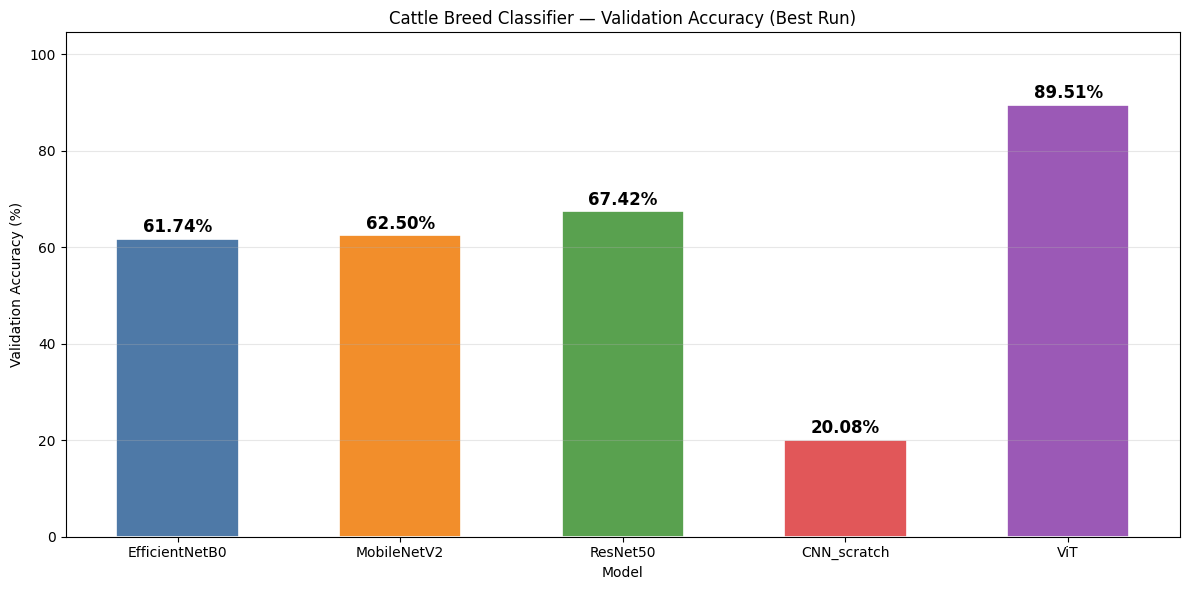


Rank  Model                 Val Accuracy
🥇     ViT                         89.51%  ◄ BEST
🥈     ResNet50                    67.42%
🥉     MobileNetV2                 62.50%
 4th  EfficientNetB0              61.74%
 5th  CNN_scratch                 20.08%


In [19]:
# ══════════════════════════════════════════════════
# CELL 11 — Final Comparison Chart + Leaderboard
# ══════════════════════════════════════════════════

# Manually fill in any model you skipped:
# all_results.update({'EfficientNetB0': 85.0, 'MobileNetV2': 82.0,
#                     'ResNet50': 80.0, 'CNN_scratch': 65.0, 'ViT': 88.0})

results_path = os.path.join(OUTPUT_DIR, 'all_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print('Results saved:', results_path)
print(json.dumps(all_results, indent=2))

model_names = ['EfficientNetB0', 'MobileNetV2', 'ResNet50', 'CNN_scratch', 'ViT']
colors      = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#9b59b6']
accs        = [all_results.get(m, 0.0) for m in model_names]

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, accs, color=colors, edgecolor='white',
              linewidth=1.2, width=0.55)
for bar, val in zip(bars, accs):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
max_acc = max(accs) if any(a > 0 for a in accs) else 100
ax.set(xlabel='Model', ylabel='Validation Accuracy (%)',
       title='Cattle Breed Classifier — Validation Accuracy (Best Run)',
       ylim=[0, min(115, max_acc + 15)])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'all_models_comparison.png')
plt.savefig(chart_path, dpi=150)
plt.show()

# ── Leaderboard ────────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'{"Rank":<6}{"Model":<20}{"Val Accuracy":>14}')
print('=' * 60)
medals = ['🥇', '🥈', '🥉', ' 4th', ' 5th']
rows   = sorted(zip(model_names, accs), key=lambda x: x[1], reverse=True)
for i, (name, val) in enumerate(rows):
    tag = '  ◄ BEST' if i == 0 else ''
    print(f'{medals[i]:<6}{name:<20}{f"{val:.2f}%":>14}{tag}')
print('=' * 60)
